Find the 20 most similar molecules to cetirizine in the Enamine REAL database and show their SMILES, similarity score and price? In the second step, generate a 4x5 plot with retrieved molecules.

In [1]:
from deepmedchem import Client

DATABASE = "enamine-real-v5a"
CETIRIZINE_SMILES = "OC(=O)COCCN1CCN(CC1)C(c1ccc(Cl)cc1)c1ccccc1"

with Client() as dmc:
    result = dmc.search(CETIRIZINE_SMILES, database=DATABASE, method="shape", limit=20)

for hit in result.hits:
    price = f"${hit.price}" if hit.price is not None else "unavailable"
    print(f"{hit.rank}  score={hit.score:.4f}  price={price}  {hit.smiles}")

1  score=0.9464  price=$163  O=C(O)COCOCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1
2  score=0.8190  price=$163  O=C(COCCN1CCCCC1)N1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1
3  score=0.7351  price=$163  CC(OC(=O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1)c1ccc(Cl)cc1
4  score=0.7351  price=$163  O=C(O)COCCNC(=O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1
5  score=0.7350  price=$163  O=C(COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1)OCCN1CCC1
6  score=0.7325  price=$163  CC(OC(=O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1)c1ccccc1
7  score=0.7277  price=$163  O=C(O)COC1CN(C(=O)COCCN2CCN(C(c3ccccc3)c3ccc(Cl)cc3)CC2)C1
8  score=0.7178  price=$245  O=C(O)CN1CCN(C(=O)COCCN2CCN(C(c3ccccc3)c3ccc(Cl)cc3)CC2)CC1
9  score=0.7136  price=$163  C[C@@H](NC(=O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1)c1ccccc1
10  score=0.7136  price=$163  C[C@H](NC(=O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1)c1ccccc1
11  score=0.7136  price=$163  CC(NC(=O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1)c1ccccc1
12  score=0.7115  price=$163  CC(NC(=O)COCCN1CCN(C(c2ccccc2)c2cc

### Step 2 — 4x5 grid of the retrieved molecules

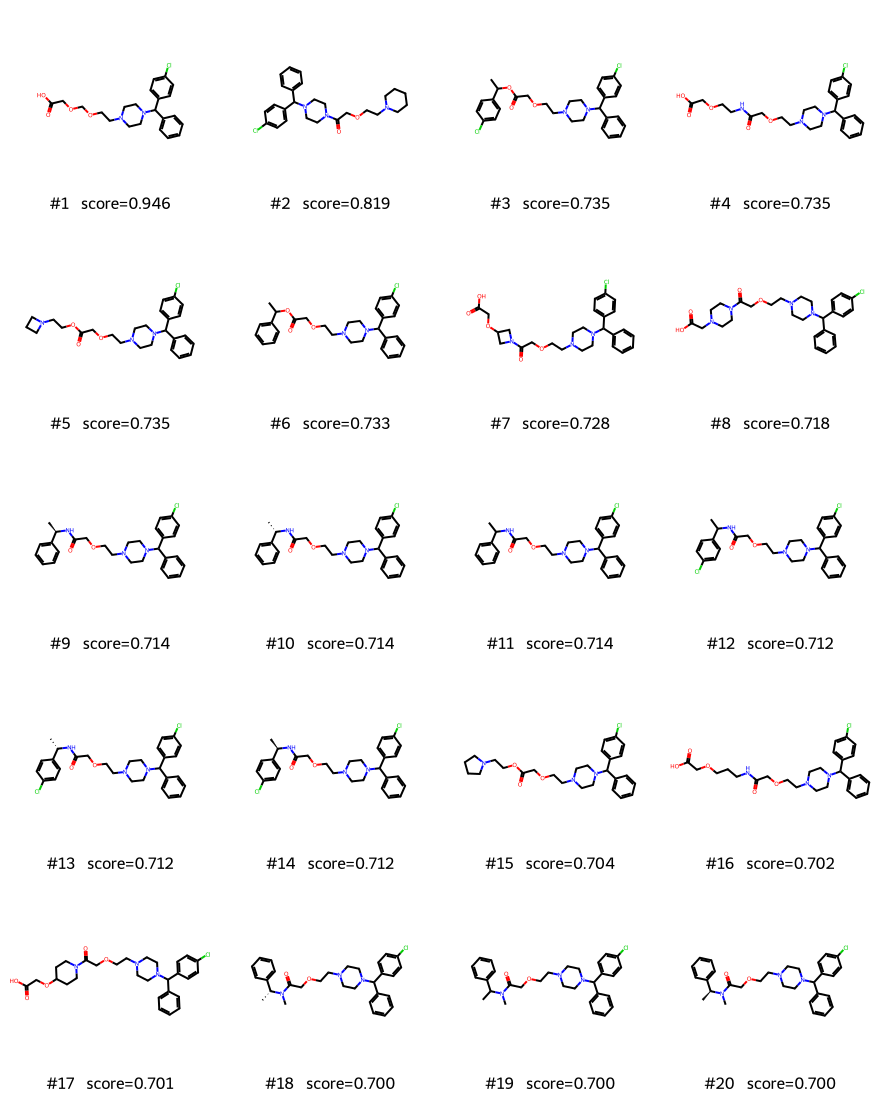

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(hit.smiles) for hit in result.hits]
legends = [f"#{hit.rank}  score={hit.score:.3f}" for hit in result.hits]

Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)